# EDA

## Cell 1 — Install & Import Everything

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# Styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

print("✅ Libraries ready")

✅ Libraries ready


## Cell 2 — Upload + Build DB + Load Master DF

In [ ]:
from google.colab import files

# 1. Upload CSV
uploaded = files.upload()  # select your CSV file

# 2. Clean
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw.columns = [c.strip().lower().replace(" ", "_") for c in df_raw.columns]
df_raw["totalcharges"] = pd.to_numeric(df_raw["totalcharges"], errors="coerce")
df_raw.rename(columns={
    "customerid":       "customer_id",
    "seniorcitizen":    "senior_citizen",
    "phoneservice":     "phone_service",
    "multiplelines":    "multiple_lines",
    "internetservice":  "internet_service",
    "onlinesecurity":   "online_security",
    "onlinebackup":     "online_backup",
    "deviceprotection": "device_protection",
    "techsupport":      "tech_support",
    "streamingtv":      "streaming_tv",
    "streamingmovies":  "streaming_movies",
    "paperlessbilling": "paperless_billing",
    "paymentmethod":    "payment_method",
    "monthlycharges":   "monthly_charges",
    "totalcharges":     "total_charges",
}, inplace=True)

# 3. SQLite
conn = sqlite3.connect("churn.db")
df_raw[["customer_id", "gender", "senior_citizen", "partner", "dependents"]]\
    .to_sql("customers", conn, if_exists="replace", index=False)
df_raw[["customer_id", "phone_service", "multiple_lines", "internet_service",
        "online_security", "online_backup", "device_protection",
        "tech_support", "streaming_tv", "streaming_movies"]]\
    .to_sql("services", conn, if_exists="replace", index=False)
df_raw[["customer_id", "tenure", "contract", "paperless_billing",
        "payment_method", "monthly_charges", "total_charges", "churn"]]\
    .to_sql("accounts", conn, if_exists="replace", index=False)

# 4. Master join
df = pd.read_sql_query("""
    SELECT c.*, s.*, a.*
    FROM customers c
    JOIN services s ON c.customer_id = s.customer_id
    JOIN accounts a ON c.customer_id = a.customer_id
""", conn)
df = df.loc[:, ~df.columns.duplicated()]

print(f"✅ All set! Shape: {df.shape}")
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
✅ All set! Shape: (7043, 21)


,customer_id,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,...,tech_support,streaming_tv,streaming_movies,tenure,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cell 3 — Data Health Check

In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Rows       : {df.shape[0]}")
print(f"Columns    : {df.shape[1]}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nData types:")
print(df.dtypes)

DATASET OVERVIEW
Rows       : 7043
Columns    : 21

Missing values:
total_charges    11
dtype: int64

Data types:
customer_id           object
gender                object
senior_citizen         int64
partner               object
dependents            object
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
tenure                 int64
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                 object
dtype: object


In [ ]:
# Fix: drop the 11 rows where total_charges is null
df.dropna(subset=["total_charges"], inplace=True)

# Fix: encode churn as binary for calculations
df["churn_binary"] = (df["churn"] == "Yes").astype(int)

print("✅ Data cleaned. Rows remaining:", len(df))

✅ Data cleaned. Rows remaining: 7032


## Chapter 1 — Who Are Our Customers?

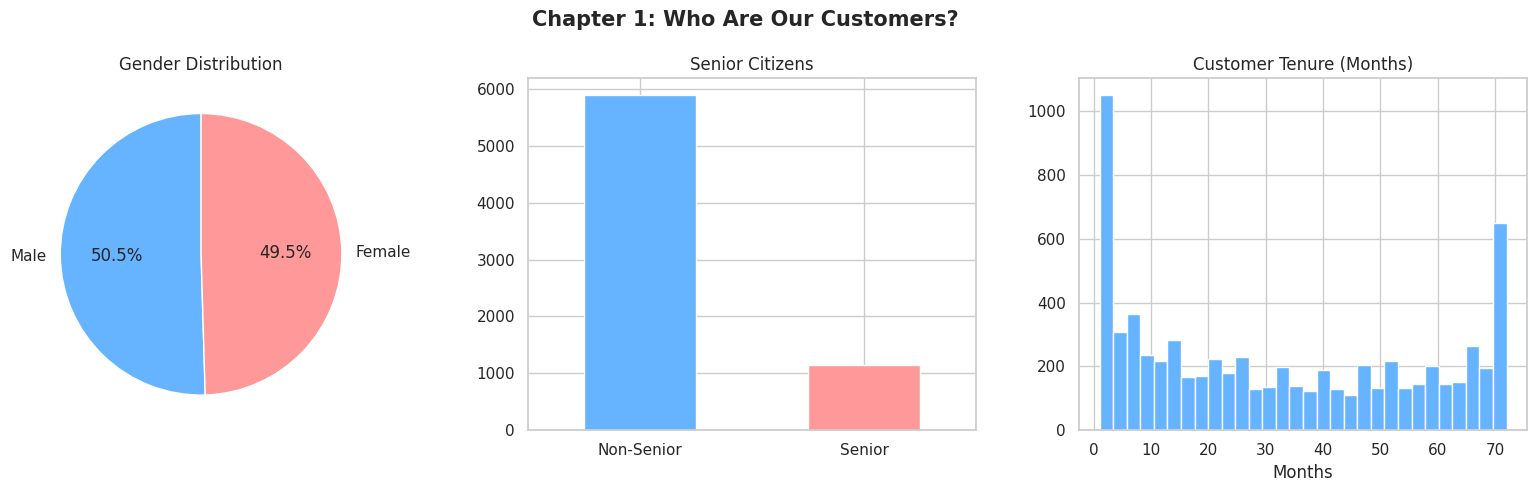

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chapter 1: Who Are Our Customers?", fontsize=15, fontweight="bold")

# Gender split
df["gender"].value_counts().plot(kind="pie", ax=axes[0], autopct="%1.1f%%",
                                  colors=["#66b3ff","#ff9999"], startangle=90)
axes[0].set_title("Gender Distribution")
axes[0].set_ylabel("")

# Senior citizens
pd.Series({
    "Non-Senior": (df["senior_citizen"] == 0).sum(),
    "Senior"    : (df["senior_citizen"] == 1).sum()
}).plot(kind="bar", ax=axes[1], color=["#66b3ff","#ff9999"], edgecolor="white")
axes[1].set_title("Senior Citizens")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Tenure distribution
axes[2].hist(df["tenure"], bins=30, color="#66b3ff", edgecolor="white")
axes[2].set_title("Customer Tenure (Months)")
axes[2].set_xlabel("Months")

plt.tight_layout()
plt.savefig("chapter1_customers.png", dpi=150)
plt.show()

In [ ]:
# 💬 Insight print — get into this habit
total = len(df)
seniors = (df["senior_citizen"] == 1).sum()
print("📌 INSIGHT — Chapter 1")
print(f"  • {seniors} customers ({seniors/total*100:.1f}%) are senior citizens")
print(f"  • Tenure is bimodal — many new customers AND long-term loyalists")
print(f"  • Gender is nearly 50/50 — not a churn driver likely")

📌 INSIGHT — Chapter 1
  • 1142 customers (16.2%) are senior citizens
  • Tenure is bimodal — many new customers AND long-term loyalists
  • Gender is nearly 50/50 — not a churn driver likely


## Chapter 2 — What Services Do They Use?

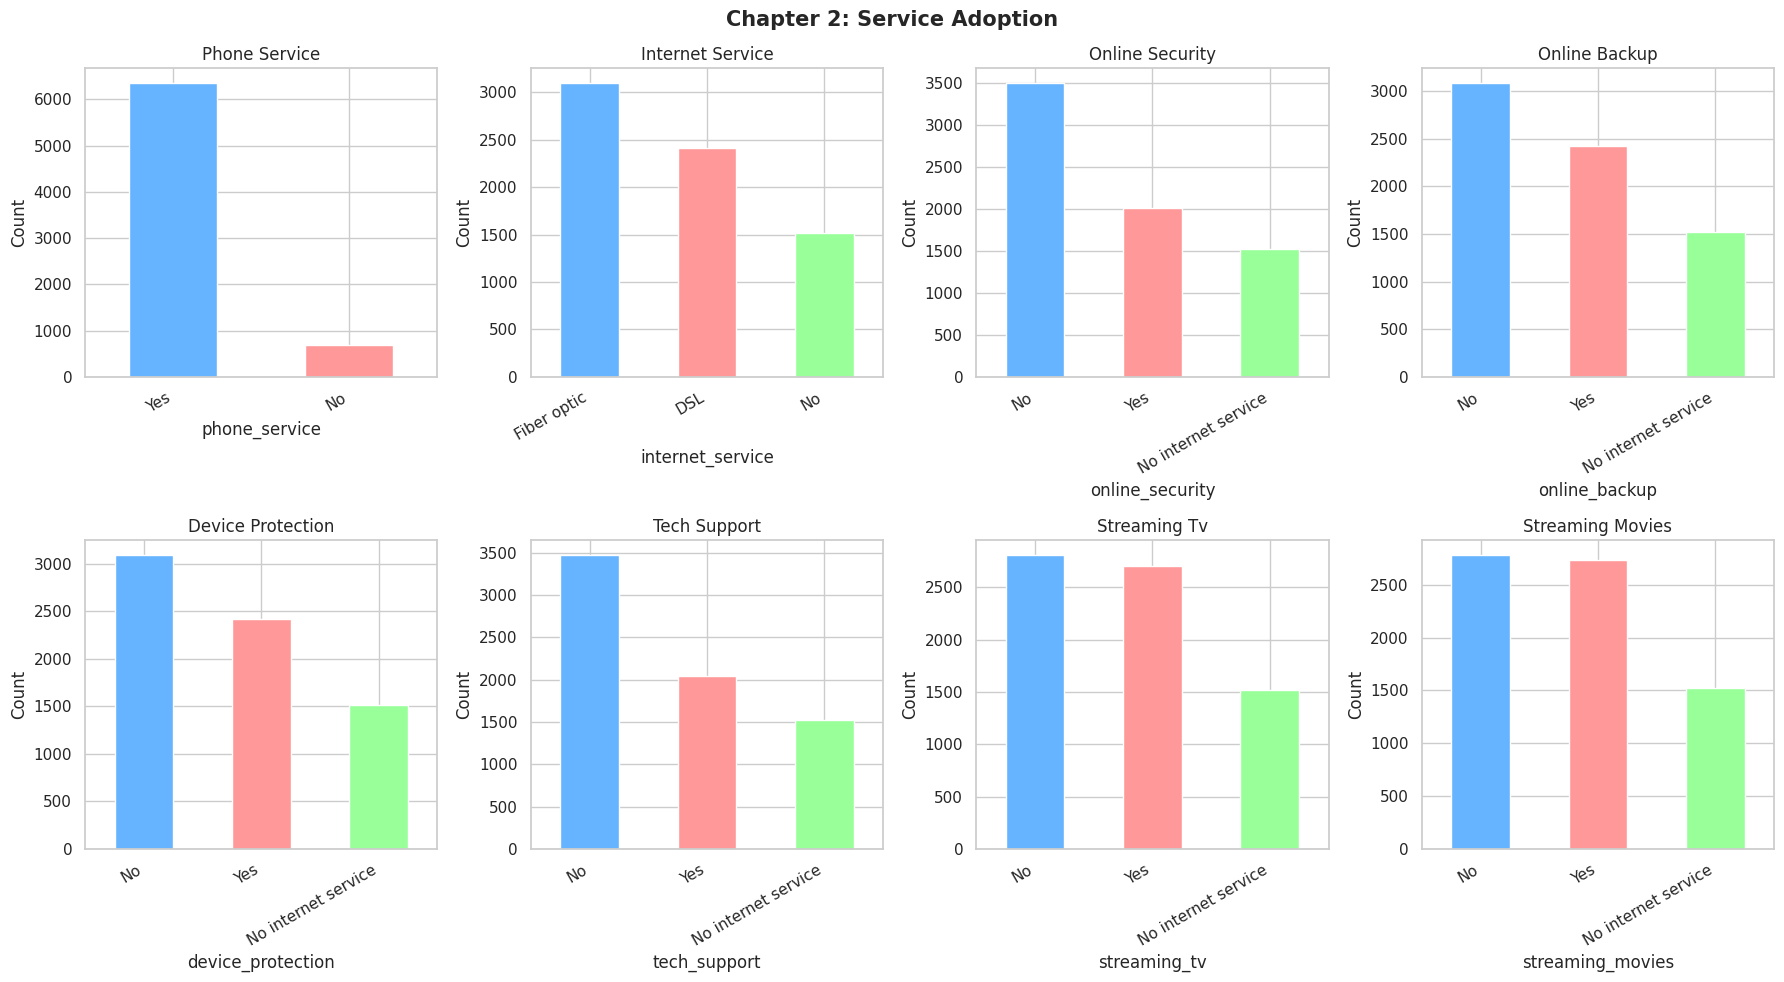

In [ ]:
service_cols = ["phone_service", "internet_service", "online_security",
                "online_backup", "device_protection", "tech_support",
                "streaming_tv", "streaming_movies"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Chapter 2: Service Adoption", fontsize=15, fontweight="bold")

for ax, col in zip(axes.flatten(), service_cols):
    df[col].value_counts().plot(kind="bar", ax=ax, color=["#66b3ff","#ff9999","#99ff99"],
                                 edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("chapter2_services.png", dpi=150)
plt.show()

##  Chapter 3 — Who Is Leaving & Why? (The Core Story)

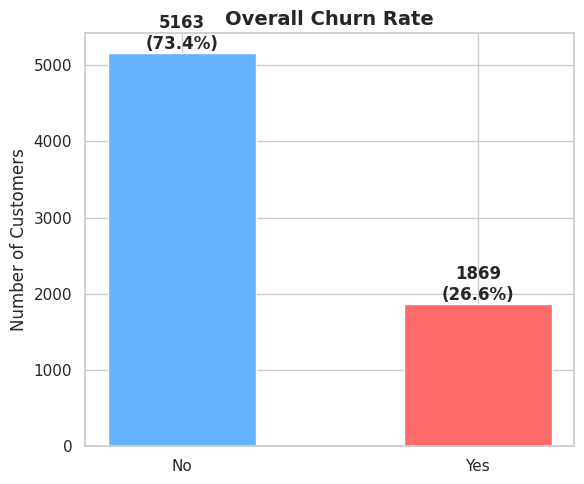

In [ ]:
# ── 3a. Overall churn rate ──
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df["churn"].value_counts()
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=["#66b3ff", "#ff6b6b"], edgecolor="white", width=0.5)

for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val}\n({val/total*100:.1f}%)", ha="center", fontweight="bold")

ax.set_title("Overall Churn Rate", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("chapter3a_churn_rate.png", dpi=150)
plt.show()

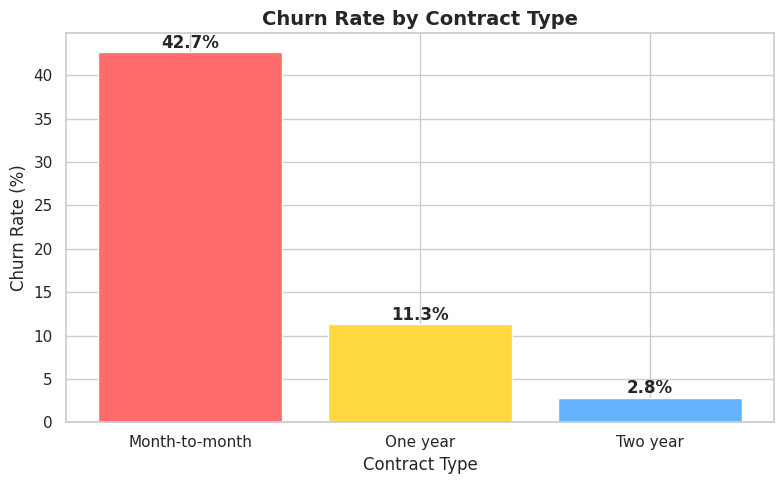

📌 INSIGHT — Contract Type
  • Month-to-month: 42.7% churn rate
  • One year: 11.3% churn rate
  • Two year: 2.8% churn rate


In [ ]:
# ── 3b. Churn by Contract Type ──
contract_churn = df.groupby("contract")["churn_binary"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=["#ff6b6b","#ffd93d","#66b3ff"], edgecolor="white")

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontweight="bold")

ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Contract Type")
plt.tight_layout()
plt.savefig("chapter3b_contract_churn.png", dpi=150)
plt.show()

print("📌 INSIGHT — Contract Type")
for contract, rate in contract_churn.items():
    print(f"  • {contract}: {rate:.1f}% churn rate")

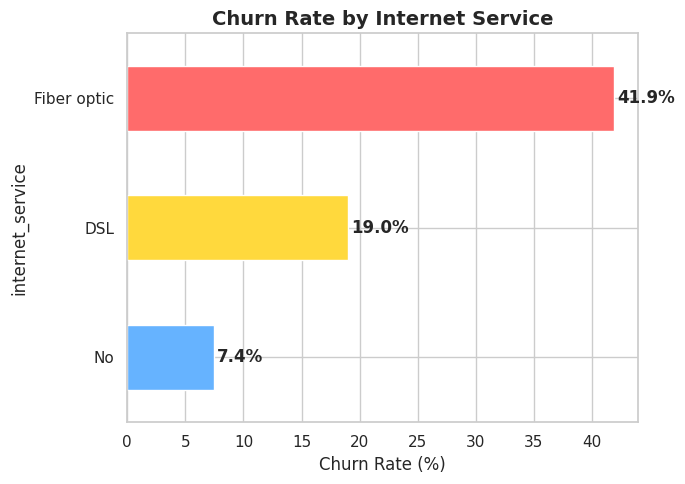

In [ ]:
# ── 3c. Churn by Internet Service ──
internet_churn = df.groupby("internet_service")["churn_binary"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
internet_churn.sort_values(ascending=True).plot(kind="barh", ax=ax,
                            color=["#66b3ff","#ffd93d","#ff6b6b"])
ax.set_title("Churn Rate by Internet Service", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn Rate (%)")

for i, v in enumerate(internet_churn.sort_values(ascending=True)):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("chapter3c_internet_churn.png", dpi=150)
plt.show()

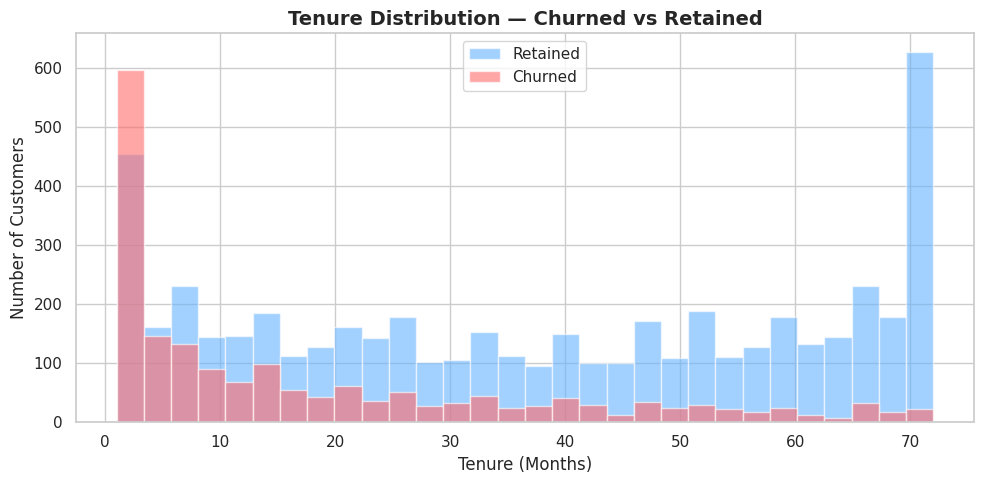

📌 INSIGHT — Tenure
  • Avg tenure (churned)  : 18.0 months
  • Avg tenure (retained) : 37.7 months
  • Most churn happens in the FIRST 12 months — critical retention window


In [ ]:
# ── 3d. Tenure vs Churn (The most powerful visual) ──
fig, ax = plt.subplots(figsize=(10, 5))
df[df["churn"] == "No"]["tenure"].hist(bins=30, alpha=0.6, label="Retained", color="#66b3ff", ax=ax)
df[df["churn"] == "Yes"]["tenure"].hist(bins=30, alpha=0.6, label="Churned", color="#ff6b6b", ax=ax)
ax.set_title("Tenure Distribution — Churned vs Retained", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.savefig("chapter3d_tenure_churn.png", dpi=150)
plt.show()

print("📌 INSIGHT — Tenure")
print(f"  • Avg tenure (churned)  : {df[df['churn']=='Yes']['tenure'].mean():.1f} months")
print(f"  • Avg tenure (retained) : {df[df['churn']=='No']['tenure'].mean():.1f} months")
print("  • Most churn happens in the FIRST 12 months — critical retention window")

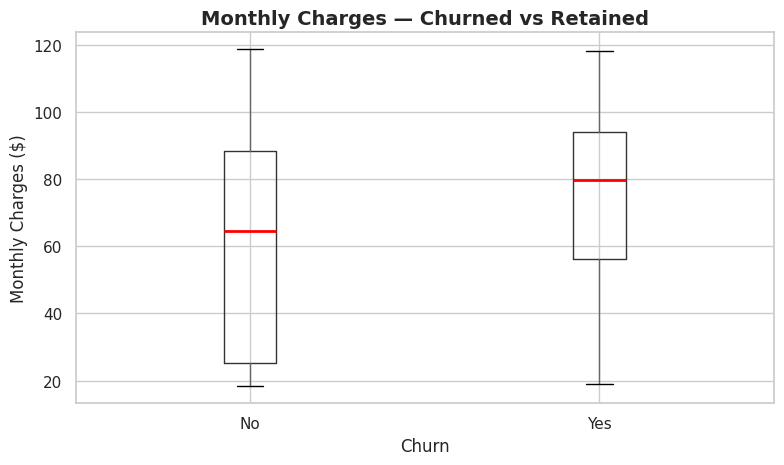

In [ ]:
# ── 3e. Monthly Charges vs Churn ──
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="monthly_charges", by="churn", ax=ax,
           boxprops=dict(color="#333"),
           medianprops=dict(color="red", linewidth=2))
ax.set_title("Monthly Charges — Churned vs Retained", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("chapter3e_charges_churn.png", dpi=150)
plt.show()

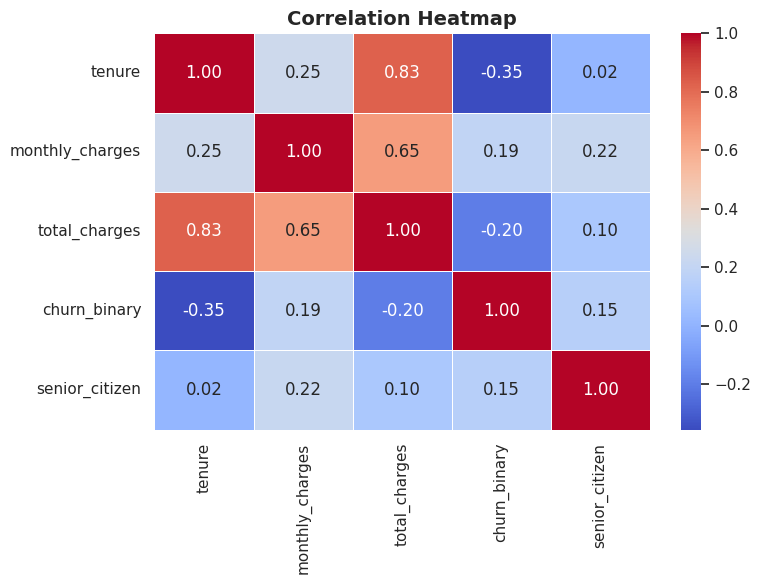

In [ ]:
# ── 3f. Correlation Heatmap ──
numeric_df = df[["tenure", "monthly_charges", "total_charges", "churn_binary", "senior_citizen"]]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chapter3f_heatmap.png", dpi=150)
plt.show()

## Cell — Final Insight Summary

In [ ]:
print("=" * 55)
print("  📊 EDA STORY SUMMARY — TELCO CHURN ANALYSIS")
print("=" * 55)
print("""
WHAT is happening?
  → 26.5% of customers have churned

WHERE is it happening?
  → Month-to-month contract customers (highest risk)
  → Fiber optic internet users
  → Customers with no add-on services (security, backup)

WHY might it be happening?
  → New customers churn fast (< 12 months tenure)
  → Higher monthly charges correlate with churn
  → Lack of service stickiness (no long-term contract)

SO WHAT should the business do?
  → Target new customers with retention offers in month 1-6
  → Incentivize annual/2-year contracts with discounts
  → Bundle online security + backup → increases stickiness
  → Review fiber optic pricing — possibly overpriced vs DSL
""")

  📊 EDA STORY SUMMARY — TELCO CHURN ANALYSIS

WHAT is happening?
  → 26.5% of customers have churned

WHERE is it happening?
  → Month-to-month contract customers (highest risk)
  → Fiber optic internet users
  → Customers with no add-on services (security, backup)

WHY might it be happening?
  → New customers churn fast (< 12 months tenure)
  → Higher monthly charges correlate with churn
  → Lack of service stickiness (no long-term contract)

SO WHAT should the business do?
  → Target new customers with retention offers in month 1-6
  → Incentivize annual/2-year contracts with discounts
  → Bundle online security + backup → increases stickiness
  → Review fiber optic pricing — possibly overpriced vs DSL



# ML

## Cell 1 — ML Imports

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils import resample
import pickle

print("✅ ML libraries ready")

✅ ML libraries ready


## Cell 2 — Prepare Features

In [ ]:
# Work on a copy — never modify the original df
ml_df = df.copy()

# Drop ID — not a feature
ml_df.drop(columns=["customer_id"], inplace=True)

# Drop total_charges — it's just tenure × monthly_charges
# Using it would be data leakage
ml_df.drop(columns=["total_charges"], inplace=True)

# Also drop churn_binary since we already have churn
ml_df.drop(columns=["churn_binary"], inplace=True)

# Encode target: Yes → 1, No → 0
ml_df["churn"] = (ml_df["churn"] == "Yes").astype(int)

# Encode all remaining categorical columns
cat_cols = ml_df.select_dtypes(include="object").columns.tolist()
print("Encoding these columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    ml_df[col] = le.fit_transform(ml_df[col])

print(f"\n✅ Ready for ML. Shape: {ml_df.shape}")
ml_df.head()

Encoding these columns: ['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

✅ Ready for ML. Shape: (7032, 19)


,gender,senior_citizen,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,tenure,contract,paperless_billing,payment_method,monthly_charges,churn
0,0,0,1,0,0,1,0,0,2,0,0,0,0,1,0,1,2,29.85,0
1,1,0,0,0,1,0,0,2,0,2,0,0,0,34,1,0,3,56.95,0
2,1,0,0,0,1,0,0,2,2,0,0,0,0,2,0,1,3,53.85,1
3,1,0,0,0,0,1,0,2,0,2,2,0,0,45,1,0,0,42.30,0
4,0,0,0,0,1,0,1,0,0,0,0,0,0,2,0,1,2,70.70,1


### Why drop total_charges? It equals tenure × monthly_charges approximately. Including it would give the model an unfair shortcut — called data leakage. Always think about whether a feature would realistically be available at prediction time.

## Cell 3 — Handle Class Imbalance

In [ ]:
majority = ml_df[ml_df["churn"] == 0]  # retained
minority = ml_df[ml_df["churn"] == 1]  # churned

print(f"Before → Retained: {len(majority)}, Churned: {len(minority)}")

# Upsample minority to match majority
minority_upsampled = resample(minority,
                              replace=True,
                              n_samples=len(majority),
                              random_state=42)

ml_balanced = pd.concat([majority, minority_upsampled])
ml_balanced = ml_balanced.sample(frac=1, random_state=42)  # shuffle

print(f"After  → Retained: {len(majority)}, Churned: {len(minority_upsampled)}")
print(f"Total  : {len(ml_balanced)}")

Before → Retained: 5163, Churned: 1869
After  → Retained: 5163, Churned: 5163
Total  : 10326


### Why balance? With 73% retained and 27% churned, a lazy model can score 73% accuracy by just predicting "No churn" every single time — completely useless. Balancing forces the model to actually learn churn patterns.

## Cell 4 — Split & Scale

In [ ]:
X = ml_balanced.drop(columns=["churn"])
y = ml_balanced["churn"]

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — brings all features to same range
# Important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

✅ Train: (8260, 18) | Test: (2066, 18)


### Why stratify=y? Ensures both train and test sets have the same churn ratio — so your test results are fair and representative.

### Why fit on train only? If you scale using the full dataset, your test set "leaks" information into training. Always fit_transform on train, only transform on test.

## Cell 5 — Model 1: Logistic Regression

In [ ]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("       LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_lr,
      target_names=["Retained", "Churned"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")

       LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    Retained       0.79      0.73      0.75      1033
     Churned       0.75      0.80      0.77      1033

    accuracy                           0.76      2066
   macro avg       0.77      0.76      0.76      2066
weighted avg       0.77      0.76      0.76      2066

ROC-AUC : 0.8438


## Cell 6 — Model 2: Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("         RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=["Retained", "Churned"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")

         RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    Retained       0.95      0.83      0.89      1033
     Churned       0.85      0.96      0.90      1033

    accuracy                           0.89      2066
   macro avg       0.90      0.89      0.89      2066
weighted avg       0.90      0.89      0.89      2066

ROC-AUC : 0.9686


## Cell 7 — ROC Curve Comparison

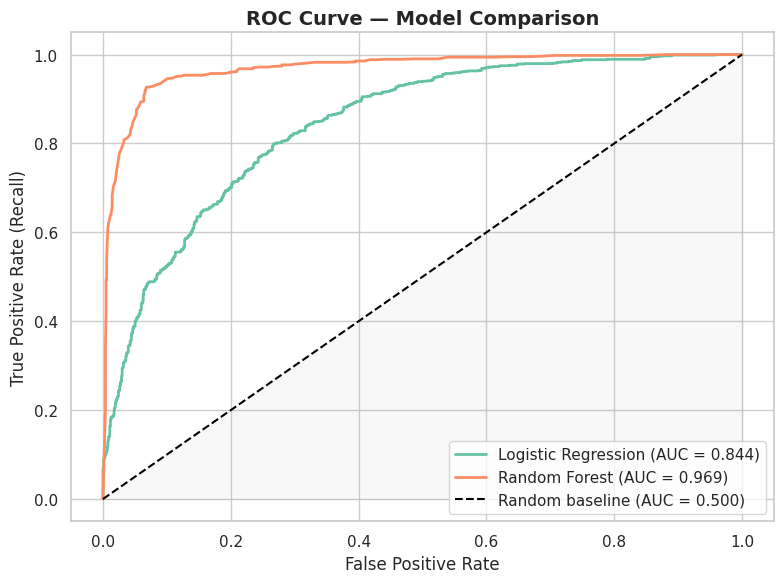

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [("Logistic Regression", y_prob_lr),
                      ("Random Forest", y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0,1], [0,1], "k--", label="Random baseline (AUC = 0.500)")
ax.fill_between([0,1], [0,1], alpha=0.05, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Model Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

### How to read AUC: 0.5 = random guessing. 0.7 = decent. 0.8+ = good. 0.9+ = excellent. The closer to 1.0, the better the model ranks high-risk customers above low-risk ones.

## Cell 8 — Confusion Matrix

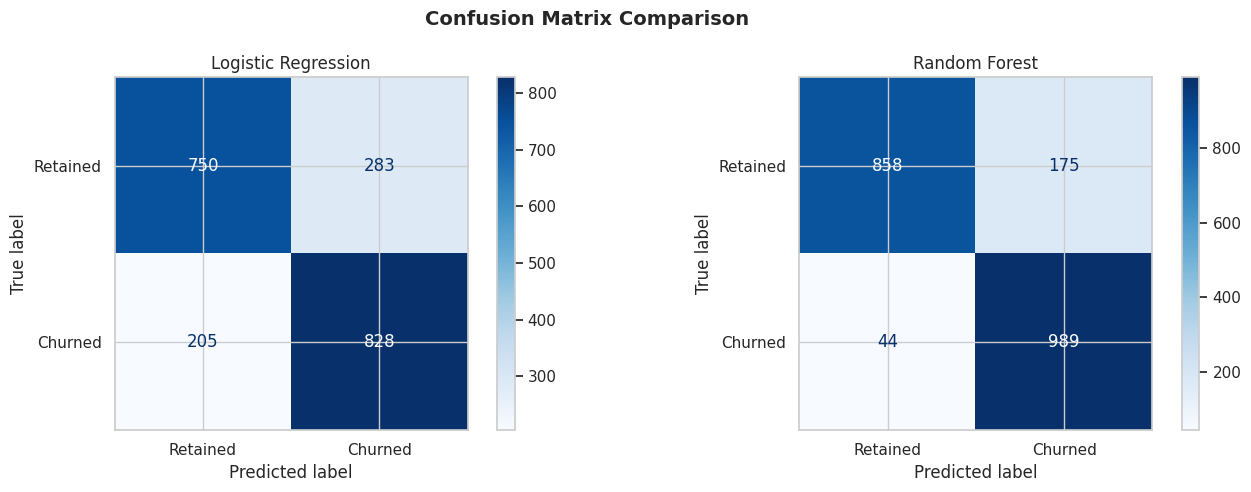

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")

for ax, model, preds, name in zip(
    axes,
    [lr, rf],
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["Retained", "Churned"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

### How to read it:
Predicted →      Retained    Churned
Actual Retained [True Neg  | False Pos]
Actual Churned  [False Neg | True Pos ]

For churn, False Negatives are costly — those are real churners the model missed. A business would rather over-warn than under-warn.

## Cell 9 — Feature Importance

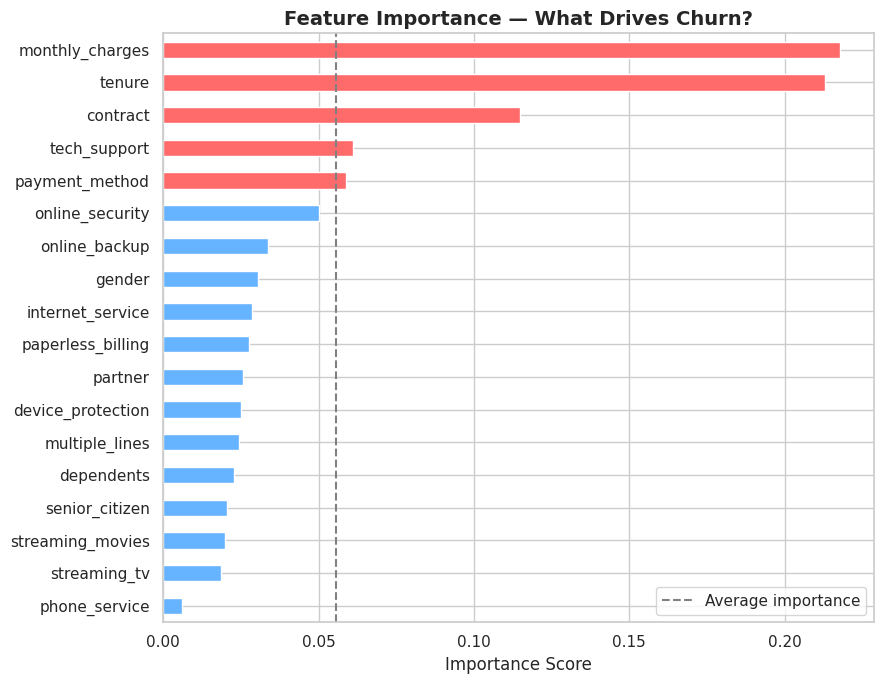


📌 Top 5 churn drivers:
  • monthly_charges          : 0.2178
  • tenure                   : 0.2131
  • contract                 : 0.1148
  • tech_support             : 0.0612
  • payment_method           : 0.0590


In [ ]:
feature_names = X.columns
importances = pd.Series(rf.feature_importances_, index=feature_names)\
                .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#ff6b6b" if i >= len(importances)-5 else "#66b3ff"
          for i in range(len(importances))]
importances.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Feature Importance — What Drives Churn?",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.axvline(x=importances.mean(), color="gray",
           linestyle="--", label="Average importance")
ax.legend()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\n📌 Top 5 churn drivers:")
for feat, score in importances.sort_values(ascending=False).head(5).items():
    print(f"  • {feat:25s}: {score:.4f}")

## Cell 10 — Save Model

In [ ]:
with open("churn_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model saved!")

# Download to your computer for GitHub
from google.colab import files
files.download("churn_model.pkl")
files.download("scaler.pkl")

✅ Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 11 — Full ML Summary

In [ ]:
lr_auc = roc_auc_score(y_test, y_prob_lr)
rf_auc = roc_auc_score(y_test, y_prob_rf)
winner = "Random Forest" if rf_auc > lr_auc else "Logistic Regression"

print("=" * 55)
print("     🤖 ML SUMMARY — CHURN PREDICTION MODEL")
print("=" * 55)
print(f"""
PROBLEM:
  Predict which customers will churn before they leave

DATA PREP:
  • Dropped customer_id (not a feature)
  • Dropped total_charges (data leakage risk)
  • Label encoded all categorical variables
  • Balanced classes via upsampling (was 73/27 split)
  • Scaled features with StandardScaler

MODELS TRAINED:
  • Logistic Regression  → AUC: {lr_auc:.4f}
  • Random Forest        → AUC: {rf_auc:.4f}
  • Winner: {winner}

BUSINESS USE:
  → Score all customers monthly with churn probability
  → Flag anyone above 0.6 probability for retention call
  → Prioritize: month-to-month + fiber + tenure < 12 months
""")

     🤖 ML SUMMARY — CHURN PREDICTION MODEL

PROBLEM:
  Predict which customers will churn before they leave

DATA PREP:
  • Dropped customer_id (not a feature)
  • Dropped total_charges (data leakage risk)
  • Label encoded all categorical variables
  • Balanced classes via upsampling (was 73/27 split)
  • Scaled features with StandardScaler

MODELS TRAINED:
  • Logistic Regression  → AUC: 0.8438
  • Random Forest        → AUC: 0.9686
  • Winner: Random Forest

BUSINESS USE:
  → Score all customers monthly with churn probability
  → Flag anyone above 0.6 probability for retention call
  → Prioritize: month-to-month + fiber + tenure < 12 months



## Dashboard

### Cell — Export Dashboard Data

In [ ]:
# Merge churn probability from RF model back to original data
df_dashboard = df.copy()

# Drop rows with nulls (the 11 we cleaned earlier)
df_dashboard.dropna(subset=["total_charges"], inplace=True)

# Prepare features for prediction (same pipeline as ML)
ml_input = df_dashboard.drop(columns=["customer_id", "total_charges", "churn_binary", "churn"])
cat_cols = ml_input.select_dtypes(include="object").columns.tolist()

le = LabelEncoder()
for col in cat_cols:
    ml_input[col] = le.fit_transform(ml_input[col])

ml_input_scaled = scaler.transform(ml_input)

# Get churn probability for every customer
churn_proba = rf.predict_proba(ml_input_scaled)[:, 1]

# Add back to dashboard dataframe
df_dashboard["churn_probability"] = churn_proba
df_dashboard["churn_probability_pct"] = (churn_proba * 100).round(1)
df_dashboard["risk_segment"] = pd.cut(
    churn_proba,
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Export
df_dashboard.to_csv("churn_dashboard.csv", index=False)
print("✅ Dashboard CSV exported!")
print(f"   Rows    : {len(df_dashboard)}")
print(f"   Columns : {df_dashboard.shape[1]}")
print(f"\nRisk segment breakdown:")
print(df_dashboard["risk_segment"].value_counts())

from google.colab import files
files.download("churn_dashboard.csv")

✅ Dashboard CSV exported!
   Rows    : 7032
   Columns : 25

Risk segment breakdown:
risk_segment
Low Risk       3794
High Risk      1866
Medium Risk     421
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>